In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import of necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Loading and nerging the daatsets

In [3]:
# Allocation of the file path to load the tourism rating dataset
toursim_rating_filepath="/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Part2/tourism_rating.csv"
tourism_rating=pd.read_csv(toursim_rating_filepath)
tourism_rating.head()

,User_Id,Place_Id,Place_Ratings
0,1,179,3
1,1,344,2
2,1,5,5
3,1,373,3
4,1,101,4


In [4]:
tourism_rating.info() # information of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   User_Id        10000 non-null  int64
 1   Place_Id       10000 non-null  int64
 2   Place_Ratings  10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


In [5]:
# Allocation of the file path to load the tourism with index dataset

toursim_id_filepath="/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Part2/tourism_with_id.xlsx"
tourism_with_id=pd.read_excel(toursim_id_filepath)
tourism_with_id.head(20)

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Unnamed: 11,Unnamed: 12
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153,NaN,1
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125,NaN,2
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538,NaN,3
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156,NaN,4
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,NaN,5
5,6,Taman Impian Jaya Ancol,Taman Impian Jaya Ancol merupakan sebuah objek...,Taman Hiburan,Jakarta,25000,4.5,10.0,"{'lat': -6.117333200000001, 'lng': 106.8579951}",-6.117333,106.857995,NaN,6
6,7,Kebun Binatang Ragunan,Kebun Binatang Ragunan adalah sebuah kebun bin...,Cagar Alam,Jakarta,4000,4.5,NaN,"{'lat': -6.3124593, 'lng': 106.8201865}",-6.312459,106.820187,NaN,7
7,8,Ocean Ecopark,Ocean Ecopark Salah satu zona rekreasi Ancol y...,Taman Hiburan,Jakarta,180000,4.0,NaN,"{'lat': -6.125801699999999, 'lng': 106.8363249}",-6.125802,106.836325,NaN,8
8,9,Pelabuhan Marina,Pelabuhan Marina Ancol berada di kawasan Taman...,Bahari,Jakarta,175000,4.4,NaN,"{'lat': 1.07888, 'lng': 103.931398}",1.078880,103.931398,NaN,9
9,10,Pulau Tidung,Pulau Tidung adalah salah satu kelurahan di ke...,Bahari,Jakarta,150000,4.5,NaN,"{'lat': -5.803205300000001, 'lng': 106.5237907}",-5.803205,106.523791,NaN,10


In [6]:
tourism_with_id.info() # getting the information of the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437 entries, 0 to 436
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Place_Id      437 non-null    int64  
 1   Place_Name    437 non-null    object 
 2   Description   437 non-null    object 
 3   Category      437 non-null    object 
 4   City          437 non-null    object 
 5   Price         437 non-null    int64  
 6   Rating        437 non-null    float64
 7   Time_Minutes  205 non-null    float64
 8   Coordinate    437 non-null    object 
 9   Lat           437 non-null    float64
 10  Long          437 non-null    float64
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   437 non-null    int64  
dtypes: float64(5), int64(3), object(5)
memory usage: 44.5+ KB


In [7]:
tourism_with_id.columns # Check the present columns in the daatset

Index(['Place_Id', 'Place_Name', 'Description', 'Category', 'City', 'Price',
       'Rating', 'Time_Minutes', 'Coordinate', 'Lat', 'Long', 'Unnamed: 11',
       'Unnamed: 12'],
      dtype='object')

In [8]:
tourism_with_id[['Unnamed: 11','Unnamed: 12']]

,Unnamed: 11,Unnamed: 12
0,NaN,1
1,NaN,2
2,NaN,3
3,NaN,4
4,NaN,5
...,...,...
432,NaN,433
433,NaN,434
434,NaN,435
435,NaN,436


These two coloumns are not necessary as they contains no values or place ID duplicate values

In [9]:
tourism_with_id.drop(['Unnamed: 11','Unnamed: 12'],axis=1,inplace=True) # dropping the unnecessary columns
tourism_with_id.head()

,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,Monumen Nasional,Monumen Nasional atau yang populer disingkat d...,Budaya,Jakarta,20000,4.6,15.0,"{'lat': -6.1753924, 'lng': 106.8271528}",-6.175392,106.827153
1,2,Kota Tua,"Kota tua di Jakarta, yang juga bernama Kota Tu...",Budaya,Jakarta,0,4.6,90.0,"{'lat': -6.137644799999999, 'lng': 106.8171245}",-6.137645,106.817125
2,3,Dunia Fantasi,Dunia Fantasi atau disebut juga Dufan adalah t...,Taman Hiburan,Jakarta,270000,4.6,360.0,"{'lat': -6.125312399999999, 'lng': 106.8335377}",-6.125312,106.833538
3,4,Taman Mini Indonesia Indah (TMII),Taman Mini Indonesia Indah merupakan suatu kaw...,Taman Hiburan,Jakarta,10000,4.5,NaN,"{'lat': -6.302445899999999, 'lng': 106.8951559}",-6.302446,106.895156
4,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134


In [10]:
# Allocation of the file path to load the user dataset

user_filepath="/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Part2/user.csv"
user=pd.read_csv(user_filepath)
user.head()

,User_Id,Location,Age
0,1,"Semarang, Jawa Tengah",20
1,2,"Bekasi, Jawa Barat",21
2,3,"Cirebon, Jawa Barat",23
3,4,"Bekasi, Jawa Barat",21
4,5,"Lampung, Sumatera Selatan",20


In [11]:
# Merge tourism_with_id_df into tourism_rating_df based on 'Place_Id'
merged_df = pd.merge(tourism_rating, tourism_with_id, on='Place_Id', how='left') # through left join because I want toursism rating data intact and only the matching values from the toursism with id merge into the dataset

# Check the result
merged_df.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151


In [12]:
merged_df['Place_Id'].value_counts() # check the unique length of the unique place_Id wheather matches with the loaded data

,count
Place_Id,
298,39
177,39
437,38
201,37
208,36
...,...
72,13
161,13
124,13


In [13]:
merged_df.info() # information of the merged dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   User_Id        10000 non-null  int64  
 1   Place_Id       10000 non-null  int64  
 2   Place_Ratings  10000 non-null  int64  
 3   Place_Name     10000 non-null  object 
 4   Description    10000 non-null  object 
 5   Category       10000 non-null  object 
 6   City           10000 non-null  object 
 7   Price          10000 non-null  int64  
 8   Rating         10000 non-null  float64
 9   Time_Minutes   4628 non-null   float64
 10  Coordinate     10000 non-null  object 
 11  Lat            10000 non-null  float64
 12  Long           10000 non-null  float64
dtypes: float64(4), int64(4), object(5)
memory usage: 1015.8+ KB


In [14]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   User_Id   300 non-null    int64 
 1   Location  300 non-null    object
 2   Age       300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB


In [15]:
 # Merge user_details_df into merged_df based on 'user_id'
final_merged_df = pd.merge(merged_df, user, on='User_Id', how='left')

# Check the result
final_merged_df.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Location,Age
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,"Semarang, Jawa Tengah",20
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,"Semarang, Jawa Tengah",20
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,"Semarang, Jawa Tengah",20
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,"Semarang, Jawa Tengah",20
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,"Semarang, Jawa Tengah",20


In [16]:
final_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   User_Id        10000 non-null  int64  
 1   Place_Id       10000 non-null  int64  
 2   Place_Ratings  10000 non-null  int64  
 3   Place_Name     10000 non-null  object 
 4   Description    10000 non-null  object 
 5   Category       10000 non-null  object 
 6   City           10000 non-null  object 
 7   Price          10000 non-null  int64  
 8   Rating         10000 non-null  float64
 9   Time_Minutes   4628 non-null   float64
 10  Coordinate     10000 non-null  object 
 11  Lat            10000 non-null  float64
 12  Long           10000 non-null  float64
 13  Location       10000 non-null  object 
 14  Age            10000 non-null  int64  
dtypes: float64(4), int64(5), object(6)
memory usage: 1.1+ MB


In [17]:
final_merged_df.columns

Index(['User_Id', 'Place_Id', 'Place_Ratings', 'Place_Name', 'Description',
       'Category', 'City', 'Price', 'Rating', 'Time_Minutes', 'Coordinate',
       'Lat', 'Long', 'Location', 'Age'],
      dtype='object')

In [18]:
# Check the final DataFrame
final_merged_df.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Location,Age
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,"Semarang, Jawa Tengah",20
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,"Semarang, Jawa Tengah",20
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,"Semarang, Jawa Tengah",20
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,"Semarang, Jawa Tengah",20
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,"Semarang, Jawa Tengah",20


In [19]:
final_merged_df.isnull().sum()

,0
User_Id,0
Place_Id,0
Place_Ratings,0
Place_Name,0
Description,0
Category,0
City,0
Price,0
Rating,0
Time_Minutes,5372


Only the Time_minutes columns has multiple Null values. We do not need that much this information probably.

In [20]:
df=final_merged_df.copy()
df

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Location,Age
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,"Semarang, Jawa Tengah",20
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,"Semarang, Jawa Tengah",20
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,"Semarang, Jawa Tengah",20
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,"Semarang, Jawa Tengah",20
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,"Semarang, Jawa Tengah",20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,300,425,2,Waterpark Kenjeran Surabaya,Waterpark Kenjeran Surabaya merupakan wisata k...,Taman Hiburan,Surabaya,35000,4.1,NaN,"{'lat': -7.247796300000002, 'lng': 112.7998235}",-7.247796,112.799824,"Ponorogo, Jawa Timur",26
9996,300,64,4,Museum Sasmita Loka Ahmad Yani,Museum Sasmita Loka Ahmad Yani adalah salah sa...,Budaya,Jakarta,2000,4.7,45.0,"{'lat': -6.204630300000001, 'lng': 106.8365324}",-6.204630,106.836532,"Ponorogo, Jawa Timur",26
9997,300,311,3,The Lodge Maribaya,The Lodge Maribaya adalah salah satu tempat wi...,Cagar Alam,Bandung,25000,4.3,150.0,"{'lat': -6.829411199999999, 'lng': 107.6874666}",-6.829411,107.687467,"Ponorogo, Jawa Timur",26
9998,300,279,4,Masjid Agung Trans Studio Bandung,Masjid Agung Trans Studio Bandung (TSB) berdir...,Tempat Ibadah,Bandung,0,4.8,NaN,"{'lat': -6.925963500000001, 'lng': 107.6354278}",-6.925963,107.635428,"Ponorogo, Jawa Timur",26


# 2. Exploring the data in depth

• Analyzing the age distribution of users visiting the places and rating them

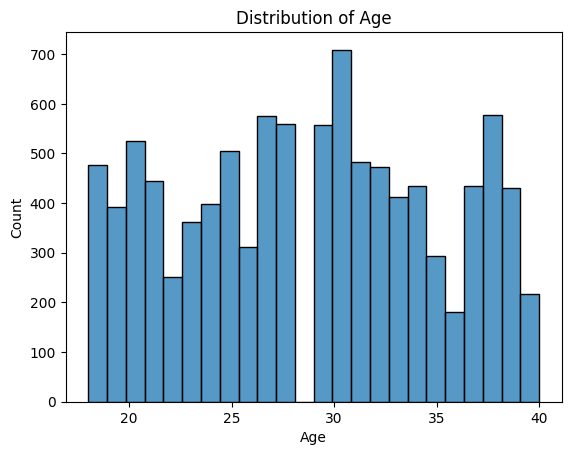

In [21]:
# Age distribution of the user visited the places
sns.histplot(df['Age'])
plt.title('Distribution of Age')
plt.show()

• Identifying the places where most of these users (tourists) are coming from

In [22]:
# Group by 'Place_Name' and count unique 'User_Id'
tourist_count_by_place = df.groupby('Place_Name')['User_Id'].nunique().reset_index()


# Sort by the number of tourists (descending order)
tourist_count_by_place = tourist_count_by_place.sort_values(by='User_Id', ascending=False)

# Check the result
tourist_count_by_place.head()

,Place_Name,User_Id
102,Gunung Lalakon,39
272,Pantai Parangtritis,35
86,Gereja Perawan Maria Tak Berdosa Surabaya,33
95,Grand Maerakaca,33
395,Taman Sungai Mudal,32


# 3. let's explore the locations and categories of tourist spots.

Diﬀerent categories of tourist spots in the data

In [23]:
df['Category'].value_counts()

,count
Category,
Taman Hiburan,3053
Budaya,2683
Cagar Alam,2415
Bahari,1079
Pusat Perbelanjaan,385
Tempat Ibadah,385


In [24]:
# Group by Place_Name and see the most frequent Category for each place
tourism_type_by_place = df.groupby('Place_Name')['Category'].apply(lambda x: x.mode()[0]).reset_index() # to get the most frequently visited places

# Check the result
print(tourism_type_by_place.head(10))

                           Place_Name       Category
0                   Air Mancur Menari  Taman Hiburan
1              Air Terjun Kali Pancur     Cagar Alam
2             Air Terjun Kedung Pedut     Cagar Alam
3                 Air Terjun Semirang     Cagar Alam
4               Air Terjun Sri Gethuk     Cagar Alam
5                  Alive Museum Ancol  Taman Hiburan
6        Alun Alun Selatan Yogyakarta  Taman Hiburan
7              Alun-Alun Kota Bandung  Taman Hiburan
8  Alun-alun Utara Keraton Yogyakarta         Budaya
9                   Amazing Art World         Budaya


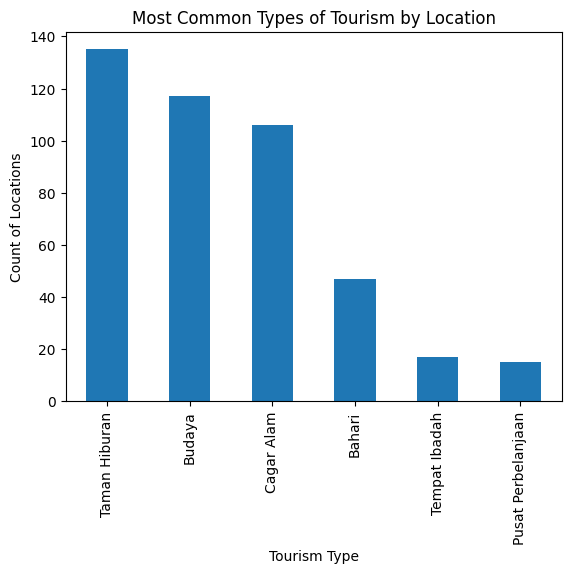

In [25]:
# Plot of the most common tourism type for each place
import matplotlib.pyplot as plt

tourism_type_by_place['Category'].value_counts().plot(kind='bar')
plt.title('Most Common Types of Tourism by Location')
plt.xlabel('Tourism Type')
plt.ylabel('Count of Locations')
plt.show()

In [26]:
df['City'].value_counts()

,count
City,
Yogyakarta,2871
Bandung,2842
Jakarta,1920
Semarang,1317
Surabaya,1050


In [27]:
# Example filter for nature-related categories
nature_tourism_df = df[df['Category'].str.contains('Cagar Alam|Nature|Eco', case=False, na=False)]

In [28]:
# Group by City and count the number of nature-related places
nature_places_by_city = nature_tourism_df.groupby('City')['Place_Name'].count().reset_index()

# Sort cities by the number of nature-related places
nature_places_by_city = nature_places_by_city.sort_values(by='Place_Name', ascending=False)

# Display the result
print(nature_places_by_city.head())

         City  Place_Name
0     Bandung        1241
4  Yogyakarta         528
2    Semarang         459
3    Surabaya         111
1     Jakarta          76


# 4. To better understand tourism, we need to create a combined data with places and their user ratings (already did before)

In [29]:
# average ratings of the places in a decreasing order
df.groupby('Place_Name')['Place_Ratings'].mean().sort_values(ascending=False) #  based on the Ratings by the users

,Place_Ratings
Place_Name,
Keraton Surabaya,3.967742
Puncak Gunung Api Purba - Nglanggeran,3.882353
Kampung Cina,3.842105
Teras Cikapundung BBWS,3.789474
Monumen Yogya Kembali,3.772727
...,...
Museum Perangko,2.238095
Amazing Art World,2.217391
Pantai Sanglen,2.214286


In [30]:
# Create the new column of  Average rating based on the ratings goiven by the users
df['Avg_rating']=df.groupby('Place_Name')['Place_Ratings'].transform('mean')
df.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Location,Age,Avg_rating
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,"Semarang, Jawa Tengah",20,3.083333
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,"Semarang, Jawa Tengah",20,2.787879
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,"Semarang, Jawa Tengah",20,3.520000
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,"Semarang, Jawa Tengah",20,2.928571
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,"Semarang, Jawa Tengah",20,2.750000


In [31]:
# most loved places based on the place's aveage rating
df_mostloved=df.groupby('Place_Name')['Avg_rating'].mean()
df_mostL=df_mostloved > 3.5 # A thrsold value
df_mostloved[df_mostL].sort_values(ascending=False)

,Avg_rating
Place_Name,
Keraton Surabaya,3.967742
Puncak Gunung Api Purba - Nglanggeran,3.882353
Kampung Cina,3.842105
Teras Cikapundung BBWS,3.789474
Monumen Yogya Kembali,3.772727
Bukit Jamur,3.766667
Bukit Bintang Yogyakarta,3.764706
Monumen Nasional,3.722222
Glamping Lakeside Rancabali,3.714286


In [32]:
# City loved based on the place ratings
df.groupby('City')['Place_Ratings'].mean().sort_values(ascending=False) #  based on the Ratings by the users

,Place_Ratings
City,
Yogyakarta,3.104493
Bandung,3.078466
Surabaya,3.072381
Semarang,3.034169
Jakarta,3.010937


In [33]:
# category of the places based on the place ratings
df.groupby('Category')['Place_Ratings'].mean().sort_values(ascending=False) #  based on the Ratings by the users

,Place_Ratings
Category,
Taman Hiburan,3.117917
Cagar Alam,3.080745
Tempat Ibadah,3.080519
Budaya,3.034663
Bahari,3.006487
Pusat Perbelanjaan,2.945455


In [63]:
df.head()

,User_Id,Place_Id,Place_Ratings,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long,Location,Age,Avg_rating
0,1,179,3,Candi Ratu Boko,Situs Ratu Baka atau Candi Boko (Hanacaraka:Í¶...,Budaya,Yogyakarta,75000,4.6,90.0,"{'lat': -7.7705416, 'lng': 110.4894158}",-7.770542,110.489416,"Semarang, Jawa Tengah",20,3.083333
1,1,344,2,Pantai Marina,Pantai Marina (bahasa Jawa: Í¶•Í¶±Í¶∂Í¶±Í¶∂Í¶Ç...,Bahari,Semarang,3000,4.1,NaN,"{'lat': -6.948877, 'lng': 110.3893285}",-6.948877,110.389329,"Semarang, Jawa Tengah",20,2.787879
2,1,5,5,Atlantis Water Adventure,Atlantis Water Adventure atau dikenal dengan A...,Taman Hiburan,Jakarta,94000,4.5,60.0,"{'lat': -6.12419, 'lng': 106.839134}",-6.124190,106.839134,"Semarang, Jawa Tengah",20,3.520000
3,1,373,3,Museum Kereta Ambarawa,Museum Kereta Api Ambarawa (bahasa Inggris: In...,Budaya,Semarang,10000,4.5,60.0,"{'lat': -7.264598899999997, 'lng': 110.4046017}",-7.264599,110.404602,"Semarang, Jawa Tengah",20,2.928571
4,1,101,4,Kampung Wisata Sosro Menduran,Kampung wisata Sosromenduran merupakan kampung...,Budaya,Yogyakarta,0,4.0,NaN,"{'lat': -7.792189999999999, 'lng': 110.362151}",-7.792190,110.362151,"Semarang, Jawa Tengah",20,2.750000


# 5. Recommendation system Building

In [111]:
# Slicing the data from the whole data set
data = df[['User_Id', 'Place_Id', 'Place_Name', 'Place_Ratings']]


In [42]:
data.info() # check the information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   User_Id        10000 non-null  int64 
 1   Place_Id       10000 non-null  int64 
 2   Place_Name     10000 non-null  object
 3   Place_Ratings  10000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 312.6+ KB


In [112]:
# missing value counts in each column of the data
data.isnull().sum()

,0
User_Id,0
Place_Id,0
Place_Name,0
Place_Ratings,0


- There is no null values in any of the columns of the sliced data set

In [45]:
data.describe() # Overall description of the data

,User_Id,Place_Id,Place_Ratings
count,10000.000000,10000.000000,10000.000000
mean,151.292700,219.416400,3.066500
std,86.137374,126.228335,1.379952
min,1.000000,1.000000,1.000000
25%,77.000000,108.750000,2.000000
50%,151.000000,220.000000,3.000000
75%,226.000000,329.000000,4.000000
max,300.000000,437.000000,5.000000


In [46]:
len(data) # length of the data

10000

In [113]:
# Calculate the number of unique user IDs in the filtered ratings dataset
len(data['User_Id'].unique())

300

In [114]:
# Calculate the number of unique Place IDs in the dataset
len(data['Place_Id'].unique())

437

In [64]:
## calculation of Average number of ratings per users ##

import statistics

# Calculate the number of ratings per user
ratings_per_user = data.groupby('User_Id')['Place_Ratings'].count()

# Calculate the mean number of ratings per user
mean_ratings_per_user = statistics.mean(ratings_per_user.tolist())
mean_ratings_per_user

33.333333333333336

__Observations:__
- The average user has rated about 33 items, indicating a weakly active engagement in rating places within the dataset.
- With an average of 33 ratings per user, the dataset shows a imbalance of user activity that is skewed by extremely active users.

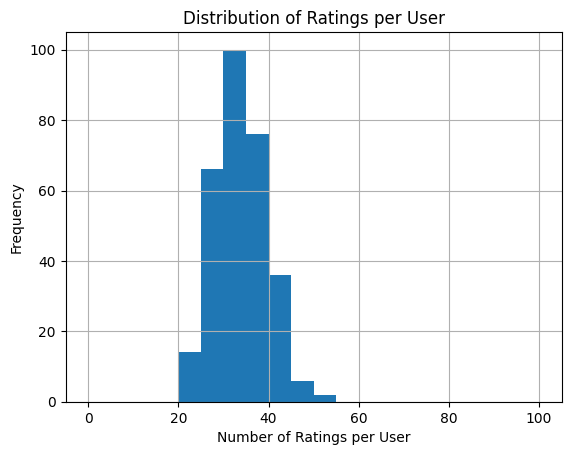

In [115]:
# visualization of per user ratings distribution
import matplotlib.pyplot as plt

# Plot a histogram of the number of ratings per user
ratings_per_user.hist(bins=20, range=(0,100))
plt.xlabel('Number of Ratings per User')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per User')
plt.show()

__Observations:__
- The distribution of ratings per user is right-skewed, with most users contributing a relatively small number of ratings, primarily below 60.
- The frequency decreases sharply as the number of ratings increases, and users with very high activity are extremely rare or absent in the dataset.

In [70]:
## calculation of Average number of ratings per place ##

# Calculate the number of ratings per place
ratings_per_place = data.groupby('Place_Id')['Place_Ratings'].count()

# Calculate the mean number of ratings per place
mean_ratings_per_place = statistics.mean(ratings_per_place.tolist())
mean_ratings_per_place

22.88329519450801

__Observations:__

- On average, each place receives approximately 23 ratings, indicating a moderate level of user engagement per location.
- However, the mean alone does not capture the distribution of ratings across places, and further analysis is required to assess variability in engagement.

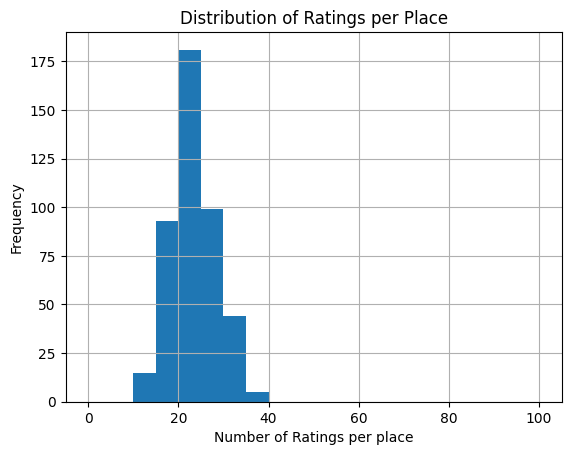

In [116]:
# visualization of per user ratings distribution

# Plot a histogram of the number of ratings per place
ratings_per_place.hist(bins=20, range=(0,100))
plt.xlabel('Number of Ratings per place')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings per Place')
plt.show()

---Observations---:

- The highest frequency of places falls within the range of approximately 10 to 40 ratings, as shown by the tallest bars in the histogram.
- Very few places receive more than 50 ratings, indicating a rapid decline in frequency as the number of ratings increases.
- The distribution is approximately symmetric, with most places receiving moderate engagement concentrated around 15–30 ratings. There is only a slight right skew, as a small number of places receive relatively higher ratings.

** **Filter place ratings greater than 30 to find the popular places with their ids**

In [230]:
# Filter the only places with 30 or more ratings
# thresold must be choosen based on the availability and need to check the sparcity in the data set after choosing the thresold
filtered_ratings_per_place = ratings_per_place[ratings_per_place >= 30]

# Extract the indices (place IDs) of popular places
popular_place = filtered_ratings_per_place.index.tolist()
len(popular_place)

49

** **Create user ratings per user greater than 35 to find the prolific users and their ids**

In [225]:
# Filter only users with 35 or more ratings
# thresold must be choosen based on the availability and need to check the sparcity in the data set after choosing the thresold
filtered_ratings_per_user_df = ratings_per_user[ratings_per_user >= 35]

# Extract the indices (user IDs) of prolific users
prolific_users = filtered_ratings_per_user_df.index.tolist()
len(prolific_users)

120

In [231]:
# Filter the ratings dataset to include only ratings for popular places
filtered_ratings_place = data[data.Place_Id.isin(popular_place)]
filtered_ratings_place

# Further filter the ratings dataset to include only ratings from prolific users
filtered_ratings_final = filtered_ratings_place[filtered_ratings_place.User_Id.isin(prolific_users)]
filtered_ratings_final

# Calculate the length of the filtered ratings dataset
len(filtered_ratings_final)

725

In [232]:
filtered_ratings_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 725 entries, 412 to 9969
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   User_Id        725 non-null    int64 
 1   Place_Id       725 non-null    int64 
 2   Place_Name     725 non-null    object
 3   Place_Ratings  725 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 28.3+ KB


In [233]:
# Create a pivot table to construct the user-place rating matrix
rating_matrix = filtered_ratings_final.pivot_table(index='User_Id', columns='Place_Id', values='Place_Ratings')

# Fill missing values (NaN) with 0
rating_matrix = rating_matrix.fillna(0)

# Display the first few rows of the user-place rating matrix
rating_matrix.head()

Place_Id,8,29,43,53,55,56,78,88,89,114,...,355,366,367,368,369,377,402,416,430,437
User_Id,,,,,,,,,,,,,,,,,,,,,
15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.0,0.0,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0
17,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
26,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
27,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0


The __user-place rating matrix__ indicates the interactions between users and places in the form of ratings. Each row represents a user, each column represents an Place id, and the values in the matrix represent the ratings given by users to the corresponding place id. This matrix provides a structured representation of user preferences and behaviors, serving as the foundation for collaborative filtering techniques to generate personalized recommendations.

- Define a function to find similar_users based on the Pierson correlation similarity of their rating vectors.

In [234]:
# Compute Pierson similarity
user_similarity = rating_matrix.T.corr()

In [235]:
def similar_users(user_id, similarity_matrix, k=5):

    if user_id not in similarity_matrix.index:
        return []

    similarities = similarity_matrix.loc[user_id].drop(user_id)

    # Fill NaN instead of dropping everything
    similarities = similarities.fillna(0)

    # Sort
    similarities = similarities.sort_values(ascending=False)

    return similarities.head(k).index.tolist()

In [236]:
current_user = 2

similar_user_indices = similar_users(current_user, user_similarity)

print(similar_user_indices)

[]


- Blank list means no strong similar users were found due to sparse or non-overlapping data. Lets chaeck for another user

In [240]:
current_user = 19

similar_user_indices = similar_users(current_user, user_similarity)

print(similar_user_indices)

[137, 143, 261, 58, 273]


* **Check the sparcity in the data matrix**

In [241]:
# Total cells
total_cells = rating_matrix.shape[0] * rating_matrix.shape[1]

# Non-zero (actual ratings)
non_zero = (rating_matrix != 0).sum().sum()

# Sparsity %
sparsity = 1 - (non_zero / total_cells)

print("Sparsity:", sparsity)

Sparsity: 0.8840136054421769


In [242]:
# Check the overlap between two users chossen in such a way that they are presnt in the rating matrix
user1 = rating_matrix.loc[19]
user2 = rating_matrix.loc[31]

# Find common rated items
common = ((user1 != 0) & (user2 != 0)).sum()

print("Common place between user 22 and 10:", common)

Common place between user 22 and 10: 0


In [243]:
# Check th overlap between two users
user1 = rating_matrix.loc[2]
user2 = rating_matrix.loc[31]

# Find common rated items
common = ((user1 != 0) & (user2 != 0)).sum()

print("Common items between user 22 and 10:", common)

KeyError: 2

 Pearson fails due to no overlap between these two users

In [247]:
# Check the similarity factors of user 19
sim = user_similarity.loc[19] # Check the pearson similarity of user 19
print(sim.head(20).sort_values(ascending=False))

User_Id
19    1.000000
58    0.388918
40    0.294442
45    0.171050
44    0.158698
55    0.073134
53    0.063299
27    0.027424
57    0.025341
28    0.000622
61   -0.073946
54   -0.092003
49   -0.107652
30   -0.119018
31   -0.132459
15   -0.138123
17   -0.139981
33   -0.169992
38   -0.172466
26   -0.183214
Name: 19, dtype: float64


simlarity factors of user 19 with the other users. It looks user 58 has similar user behaviour

In [248]:
print(sim.describe()) # descrives how many similar users are apresent with user 19

count    120.000000
mean       0.006807
std        0.173909
min       -0.190401
25%       -0.118549
50%       -0.052956
75%        0.078785
max        1.000000
Name: 19, dtype: float64


# Lets try for cosine similarities

- Define function to find similar_users based on the cosine similarity of their rating vectors.

In [249]:
from sklearn.metrics.pairwise import cosine_similarity
import operator

def similar_users(user_id, matrix, k=5):
    # Retrieve the user's vector from the rating matrix
    user = matrix[matrix.index == user_id]

    # Exclude the user's vector from the rating matrix
    other_users = matrix[matrix.index != user_id]

    # Calculate cosine similarity between the user and other users
    similarities = cosine_similarity(user, other_users)[0].tolist()

    # Get the indices (user IDs) of other users
    indices = other_users.index.tolist()

    # Create a dictionary mapping indices to similarity scores
    index_similarity = dict(zip(indices, similarities))

    # Sort the dictionary by similarity scores in descending order
    index_similarity_sorted = sorted(index_similarity.items(), key=operator.itemgetter(1))
    index_similarity_sorted.reverse()

    # Get the top k similar users
    top_users_similarities = index_similarity_sorted[:k]
    users = [u[0] for u in top_users_similarities]

    return users

- Test the similar_users function with a sample user ID.

In [250]:
# Define the current user's ID
current_user = 17

# Find indices of similar users to the current user
similar_user_indices = similar_users(current_user, rating_matrix)

# Print the indices of similar users
print(similar_user_indices)

[33, 274, 288, 167, 49]


- Define a function to recommend places for a user based on the average ratings of similar users.
- Test the recommend_places function with a sample user ID and similar user indices.

In [251]:
def recommend_item(user_index, similar_user_indices, matrix, items=5):
    # Select rows corresponding to similar users
    similar_users = matrix[matrix.index.isin(similar_user_indices)]

    # Calculate the mean rating for each places among similar users
    similar_users = similar_users.mean(axis=0)

    # Convert the result to a DataFrame
    similar_users_df = pd.DataFrame(similar_users, columns=['mean'])

    # Select the target user's ratings
    user_df = matrix[matrix.index == user_index]

    # Transpose the DataFrame for easier manipulation
    user_df_transposed = user_df.transpose()

    # Rename the column for clarity
    user_df_transposed.columns = ['Place_Ratings']

    # Filter out items that the target user has already rated
    user_df_transposed = user_df_transposed[user_df_transposed['Place_Ratings']==0]

    # Extract the indices (Place IDs) of unseen places
    places_unseen = user_df_transposed.index.tolist()

    # Filter the DataFrame to include only ratings for unseen places
    similar_users_df_filtered = similar_users_df[similar_users_df.index.isin(places_unseen)]

    # Sort the DataFrame by mean rating in descending order
    similar_users_df_ordered = similar_users_df_filtered.sort_values(by=['mean'], ascending=False)

    # Select the top n places with the highest mean rating
    top_n_places = similar_users_df_ordered.head(items)
    top_n_places_indices = top_n_places.index.tolist()

    # Retrieve information about the recommended places from the 'tourism_with_id' dataset
    place_information = tourism_with_id[tourism_with_id['Place_Id'].isin(top_n_places_indices)]

    return place_information


In [252]:
current_user = int(input('index of the user Id: ',))
# recommndation of the five place to the current user based on the rating of the similar users
recommend_item(current_user, similar_user_indices, rating_matrix)

index of the user Id: 17


,Place_Id,Place_Name,Description,Category,City,Price,Rating,Time_Minutes,Coordinate,Lat,Long
7,8,Ocean Ecopark,Ocean Ecopark Salah satu zona rekreasi Ancol y...,Taman Hiburan,Jakarta,180000,4.0,NaN,"{'lat': -6.125801699999999, 'lng': 106.8363249}",-6.125802,106.836325
113,114,The Lost World Castle,The Lost World Castle merupakan salah satu obj...,Taman Hiburan,Yogyakarta,30000,4.3,NaN,"{'lat': -7.6041648, 'lng': 110.4510042}",-7.604165,110.451004
126,127,Blue Lagoon Jogja,Blue Lagoon adalah salah satu wisata air Jogja...,Taman Hiburan,Yogyakarta,10000,4.3,NaN,"{'lat': -7.7044358, 'lng': 110.45026}",-7.704436,110.450260
196,197,Pantai Jungwok,Pantai Jungwok adalah pantai yang terletak di ...,Bahari,Yogyakarta,5000,4.6,NaN,"{'lat': -8.197822, 'lng': 110.7123397}",-8.197822,110.712340
415,416,Keraton Surabaya,Kawasan yang berjuluk Kampung Keraton ini terd...,Budaya,Surabaya,0,4.4,NaN,"{'lat': -7.256755299999998, 'lng': 112.7942203}",-7.256755,112.794220


__Observation:__

- The function successfully generates personalized place recommendations for a user ID "gven as input" by averaging the ratings of similar users and suggesting titles that the target user has not yet rated.